In [38]:
! pip install optuna 

In [39]:
!pip install optuna-integration[xgboost]

In [70]:
import json
import numpy as np
import pandas as pd
import joblib
import optuna
import xgboost as xgb
from xgboost import XGBRegressor
from optuna.integration import XGBoostPruningCallback

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv("/kaggle/input/datasets/aryansharmabf/delhi-aqi-prediction/delhi_2000_2025_extended.csv")

/kaggle/input/datasets/aryansharmabf/delhi-aqi-prediction/delhi_2000_2025_extended.csv


In [41]:
df.head()

,location_id,city,Time,temperature,humidity,pressure,wind_speed,wind_direction,pm25,pm10,no2,so2,o3,co,aqi
0,"Delhi Institute of Tool Engineering, Wazirpur,...",Wazirpur,2000-03-15 13:44:28.651396,30.45,74.100,990.425,0.300,21.7,252.0,332.0,62.4,4.8,22.4,35.7,332.0
1,"Pusa, Delhi, Delhi, India",Pusa,2000-03-15 13:44:28.651396,27.25,74.350,983.875,0.300,180.4,239.0,315.0,36.6,1.6,0.8,8.5,315.0
2,"Mandir Marg, Delhi, Delhi, India",Mandir Marg,2000-03-15 13:44:28.651396,29.95,91.600,985.825,0.300,323.8,208.0,127.0,33.6,0.9,8.9,5.2,208.0
3,"Major Dhyan Chand National Stadium, Delhi, Del...",Major Dhyan Chand National Stadium,2000-03-15 13:44:28.651396,25.70,67.625,987.025,0.225,346.4,230.0,181.0,85.7,10.3,6.7,22.9,230.0
4,"R.K. Puram, Delhi, Delhi, India",R.K. Puram,2000-03-15 13:44:28.651396,24.90,81.500,980.400,0.300,148.0,310.0,450.0,36.1,4.9,7.0,20.4,450.0


In [42]:
TAIL_OUT = "recent_tail.csv"

# Parse time

In [43]:
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df = df.dropna(subset=["Time"]).sort_values("Time").reset_index(drop=True)

# Replace '-' if present

In [44]:
df.replace("-",np.nan,inplace = True)

# Numeric conversion

In [45]:
num_cols = [
    "temperature","humidity","pressure","wind_speed","wind_direction",
    "pm25","pm10","no2","so2","o3","co","aqi"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c],errors = "coerce")

# Remove duplicates

In [46]:
df = df.drop_duplicates()

# AQI clip (sensor glitches)

In [47]:
if "aqi" in df.columns:
    df["aqi"] = df["aqi"].clip(lower=0, upper=800)
else:
    raise ValueError("Column 'aqi' not found in dataset.")

# B) Handle Missing (Hybrid time-series)

In [48]:
if "location_id" not in df.columns:
    df["location_id"] = "global"

df = df.sort_values(["location_id", "Time"]).reset_index(drop=True)

weather_cols   = ["temperature", "humidity", "pressure", "wind_speed"]
pollutant_cols = ["pm25", "pm10", "no2", "so2", "o3", "co"]

def hybrid_fill(colname: str):
    """1) interpolate per location (safe), 2) (location, month) mean fallback, 3) ffill/bfill"""
    if colname not in df.columns:
        return

    # ensure numeric
    df[colname] = pd.to_numeric(df[colname], errors="coerce")

    # 1) location-wise interpolation (SAFE: transform keeps same index)
    df[colname] = df.groupby("location_id")[colname].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

    # 2) monthly fallback (more accurate: per location + month)
    monthly_avg = df.groupby(["location_id", df["Time"].dt.month])[colname].transform("mean")
    df[colname] = df[colname].fillna(monthly_avg)

    # 3) edge fill
    df[colname] = df[colname].ffill().bfill()

for c in weather_cols + pollutant_cols:
    hybrid_fill(c)

# Wind direction: interpolate + circular encoding

In [49]:
if "wind_direction" in df.columns:
    df["wind_direction"] = pd.to_numeric(df["wind_direction"], errors="coerce")

    df["wind_direction"] = df.groupby("location_id")["wind_direction"].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

    monthly_avg_wd = df.groupby(["location_id", df["Time"].dt.month])["wind_direction"].transform("mean")
    df["wind_direction"] = df["wind_direction"].fillna(monthly_avg_wd).ffill().bfill()

    # keep in 0..360 just in case
    df["wind_direction"] = df["wind_direction"].clip(lower=0, upper=360)

    df["wind_dir_sin"] = np.sin(np.deg2rad(df["wind_direction"]))
    df["wind_dir_cos"] = np.cos(np.deg2rad(df["wind_direction"]))
else:
    # Safety: if not present, create neutral features
    df["wind_dir_sin"] = 0.0
    df["wind_dir_cos"] = 0.0

# Final safety: clip negatives for numeric features

In [51]:
for c in weather_cols + pollutant_cols:
    if c in df.columns:
        df[c] = df[c].clip(lower=0)


# C) Time features

In [52]:
df["Year"]      = df["Time"].dt.year
df["Month"]     = df["Time"].dt.month
df["Day"]       = df["Time"].dt.day
df["Dayofweek"] = df["Time"].dt.dayofweek
df["Hour"]      = df["Time"].dt.hour

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)


# D) Encode categorical (city/location)


In [53]:
le_location = LabelEncoder()
df["location_id_encoded"] = le_location.fit_transform(df["location_id"].astype(str))

if "city" in df.columns:
    le_city = LabelEncoder()
    df["city_encoded"] = le_city.fit_transform(df["city"].astype(str))
else:
    le_city = None
    df["city_encoded"] = 0

# E) Lag/Roll features (NO leakage)

In [54]:

# IMPORTANT: rolling mean should not include current timestep -> shift(1)
lag_base = ["pm25","pm10","no2","so2","o3","co","aqi"]

for col in lag_base:
    if col not in df.columns:
        continue

    for lag in [1, 2, 3]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # roll3 uses only past values
    df[f"{col}_roll3"] = df[col].rolling(3).mean().shift(1)

# Drop initial NaNs from lag/roll
df = df.dropna().reset_index(drop=True)

# F) Feature list

In [56]:
FEATURES = [
    # weather + wind
    "temperature","humidity","pressure","wind_speed",
    "wind_dir_sin","wind_dir_cos",

    # pollutants current
    "pm25","pm10","no2","so2","o3","co",

    # time
    "Year","Month","Day","Dayofweek","Hour_sin","Hour_cos",

    # encodings
    "location_id_encoded","city_encoded",
]

# add lag/roll features

In [57]:
for col in ["pm25","pm10","no2","so2","o3","co","aqi"]:
    for lag in [1,2,3]:
        FEATURES.append(f"{col}_lag{lag}")
    FEATURES.append(f"{col}_roll3")

TARGET = "aqi"

# G) Scale + time split

In [58]:
X = df[FEATURES].astype(float)
y = df[TARGET].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

split_idx = int(len(df) * 0.8)  # time-series split
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# F) Feature list

In [63]:
FEATURES = [
    # weather + wind
    "temperature","humidity","pressure","wind_speed",
    "wind_dir_sin","wind_dir_cos",

    # pollutants current
    "pm25","pm10","no2","so2","o3","co",

    # time
    "Year","Month","Day","Dayofweek","Hour_sin","Hour_cos",

    # encodings
    "location_id_encoded","city_encoded",
]

# add lag/roll features

In [64]:
for col in ["pm25","pm10","no2","so2","o3","co","aqi"]:
    for lag in [1,2,3]:
        FEATURES.append(f"{col}_lag{lag}")
    FEATURES.append(f"{col}_roll3")

TARGET = "aqi"

# G) Scale + time split

In [65]:
X = df[FEATURES].astype(float)
y = df[TARGET].astype(float)

# XGBoost ko scaling ki zarurat nahi hoti, but keep it (Streamlit consistency)

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test split (last 20%)

In [67]:
split_idx = int(len(df) * 0.8)
X_train_full, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train_full, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Validation split inside train (last 20% of train)

In [68]:
val_idx = int(len(X_train_full) * 0.8)
X_train, X_val = X_train_full[:val_idx], X_train_full[val_idx:]
y_train, y_val = y_train_full.iloc[:val_idx], y_train_full.iloc[val_idx:]


# H) Optuna Hyperparameter Tuning


In [74]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 25),
        "gamma": trial.suggest_float("gamma", 0.0, 6.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 6.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 15.0, log=True),

        "random_state": 42,
        "tree_method": "hist",
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "n_jobs": -1,
    }

    model = XGBRegressor(**params)

    # ✅ No early_stopping_rounds, no callbacks (Kaggle error fix)
    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)
    rmse_val = float(np.sqrt(mean_squared_error(y_val, pred_val)))
    return rmse_val


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40)

best_params = study.best_params
print("✅ Best RMSE (val):", study.best_value)
print("✅ Best Params:", best_params)

[I 2026-02-20 10:23:12,934] A new study created in memory with name: no-name-b5ffe700-2866-4c41-95b7-6d2d8c8d4261
[I 2026-02-20 10:26:07,337] Trial 0 finished with value: 6.30487763600972 and parameters: {'n_estimators': 1277, 'max_depth': 9, 'learning_rate': 0.019873275070743695, 'subsample': 0.9704925899833403, 'colsample_bytree': 0.7308171224974382, 'min_child_weight': 25, 'gamma': 3.0577139586684807, 'reg_alpha': 2.8955715588425326, 'reg_lambda': 5.366737153950783}. Best is trial 0 with value: 6.30487763600972.
[I 2026-02-20 10:29:42,496] Trial 1 finished with value: 9.818059051793023 and parameters: {'n_estimators': 1430, 'max_depth': 9, 'learning_rate': 0.030993501184625315, 'subsample': 0.7384249206718406, 'colsample_bytree': 0.8805936036154942, 'min_child_weight': 3, 'gamma': 0.24535782628522118, 'reg_alpha': 1.3695055248833832, 'reg_lambda': 1.315276392132887}. Best is trial 0 with value: 6.30487763600972.
[I 2026-02-20 10:31:34,810] Trial 2 finished with value: 6.192773621354

✅ Best RMSE (val): 4.673619168392201
✅ Best Params: {'n_estimators': 900, 'max_depth': 6, 'learning_rate': 0.1345963942215043, 'subsample': 0.8430552548823688, 'colsample_bytree': 0.7429714245714815, 'min_child_weight': 19, 'gamma': 1.4119863760673765, 'reg_alpha': 0.70442703464698, 'reg_lambda': 0.5353219617995876}


# Train final model on train_full with best params

In [75]:

model = XGBRegressor(
    **best_params,
    random_state=42,
    tree_method="hist",
    objective="reg:squarederror"
)

model.fit(
    X_train_full, y_train_full,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7429714245714815, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=1.4119863760673765, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1345963942215043,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=19, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, ...)

# I) Evaluate + residual std

In [79]:
pred_test = model.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
r2   = float(r2_score(y_test, pred_test))
residual_std = float(np.std(y_test - pred_test))

print("✅ Test RMSE:", rmse)
print("✅ Test R2:  ", r2)
print("✅ Residual STD:", residual_std)

✅ Test RMSE: 13.63331065733974
✅ Test R2:   0.9616021070799672
✅ Residual STD: 13.583592706875411


In [80]:
pred_test = model.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
r2 = float(r2_score(y_test, pred_test))
residual_std = float(np.std(y_test - pred_test))

RMSE: 13.63331065733974
R2: 0.9616021070799672


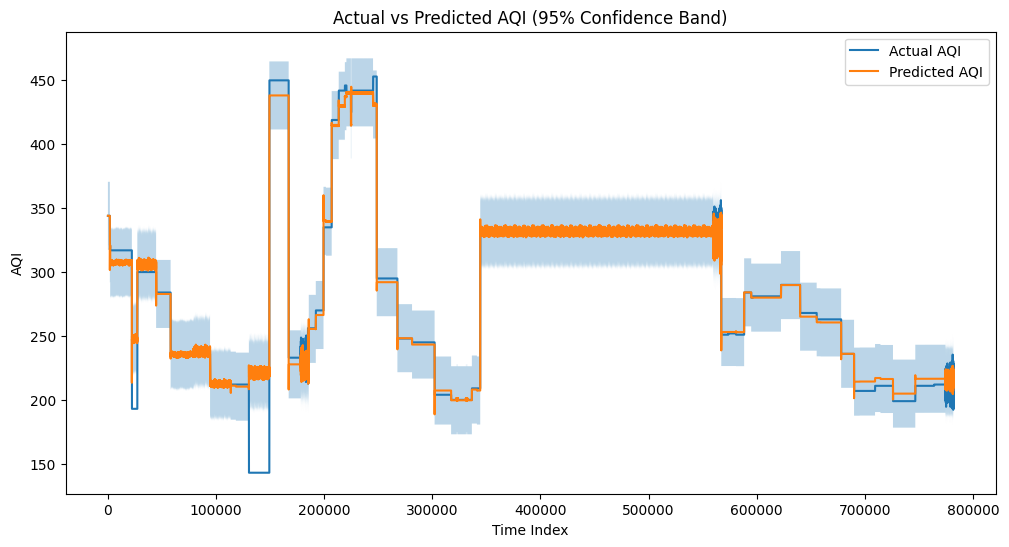

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Recalculate predictions
pred_test = model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
r2 = float(r2_score(y_test, pred_test))
residual_std = float(np.std(y_test - pred_test))

print("RMSE:", rmse)
print("R2:", r2)

y_true = np.array(y_test)
y_pred = np.array(pred_test)

lower = np.clip(y_pred - 1.96 * residual_std, 0, 800)
upper = np.clip(y_pred + 1.96 * residual_std, 0, 800)

plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.fill_between(range(len(y_pred)), lower, upper, alpha=0.3)

plt.title("Actual vs Predicted AQI (95% Confidence Band)")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.legend()
plt.show()

# J) Save artifacts

In [83]:
joblib.dump(model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURES, "feature_list.pkl")
joblib.dump(le_location, "labelencoder_location.pkl")
joblib.dump(le_city, "labelencoder_city.pkl")

['labelencoder_city.pkl']

# tail for streamlit

In [84]:
df.tail(20000).to_csv(TAIL_OUT, index=False)

with open("metrics.json", "w") as f:
    json.dump({"rmse": rmse, "r2": r2, "residual_std": residual_std}, f, indent=2)

with open("best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

print("✅ Saved: best_model.pkl, scaler.pkl, feature_list.pkl, encoders, recent_tail.csv, metrics.json, best_params.json")

✅ Saved: best_model.pkl, scaler.pkl, feature_list.pkl, encoders, recent_tail.csv, metrics.json, best_params.json
